# Base

## google drive

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
ROOT_DIR= '/content/gdrive/MyDrive/MacBook/Yolov8/'
%cd {ROOT_DIR}

/content/gdrive/MyDrive/MacBook/Yolov8


## ltralytics

In [3]:
!git clone https://github.com/ultralytics/ultralytics.git
%cd ultralytics
!pip install ultralytics
%cd {ROOT_DIR}

Cloning into 'ultralytics'...
remote: Enumerating objects: 50690, done.
remote: Counting objects: 100% (322/322), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 50690 (delta 280), reused 168 (delta 168), pack-reused 50368 (from 4)
Receiving objects: 100% (50690/50690), 28.90 MiB | 11.31 MiB/s, done.
Resolving deltas: 100% (37492/37492), done.
Updating files: 100% (689/689), done.
/content/gdrive/MyDrive/MacBook/Yolov8/ultralytics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.7/914.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8

In [4]:
!pip install Ipython
import matplotlib.pyplot as plt
from IPython.display import Image as imgshow
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.1 MB/s eta 0:00:00


----------

-------

# Detection

## command

### picture

In [5]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.5 source="input/dogs_n_cars.jpg" save=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 6.25M/6.25M [00:00<00:00, 71.0MB/s]
Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 /content/gdrive/MyDrive/MacBook/Yolov8/input/dogs_n_cars.jpg: 640x640 4 persons, 8 cars, 6 dogs, 2 cows, 521.1ms
Speed: 24.8ms preprocess, 521.1ms inference, 35.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [6]:
imgshow(os.path.join(ROOT_DIR,"runs/detect/predict/dogs_n_cars.jpg"), width = 600)

Output hidden; open in https://colab.research.google.com to view.

### video

In [7]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.5 source="input/test_vid.mp4" save=True

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

video 1/1 (frame 1/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 8 persons, 182.1ms
video 1/1 (frame 2/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 8 persons, 168.1ms
video 1/1 (frame 3/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 8 persons, 150.8ms
video 1/1 (frame 4/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 9 persons, 160.4ms
video 1/1 (frame 5/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 8 persons, 1 backpack, 151.3ms
video 1/1 (frame 6/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 8 persons, 1 backpack, 148.1ms
video 1/1 (frame 7/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 8 persons, 1 backpack, 142.6ms
video 1/1 (frame 8/272) /conten

-----------------

## code

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO
from PIL import Image

In [9]:
def get_colors(classes):
    return {cls: (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) for cls in classes}

def plot_bboxes(image, boxes, confs, classes, score=True):
    img = image.copy()
    unique_classes = set(int(cls) for cls in classes.tolist())
    colors = get_colors(unique_classes)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        color = colors[int(classes[i])]

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        label = f"{int(classes[i])}"
        if score:
            label += f" {confs[i]:.2f}"

        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


0: 640x640 4 persons, 9 cars, 8 dogs, 1 cow, 269.8ms
Speed: 10.7ms preprocess, 269.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


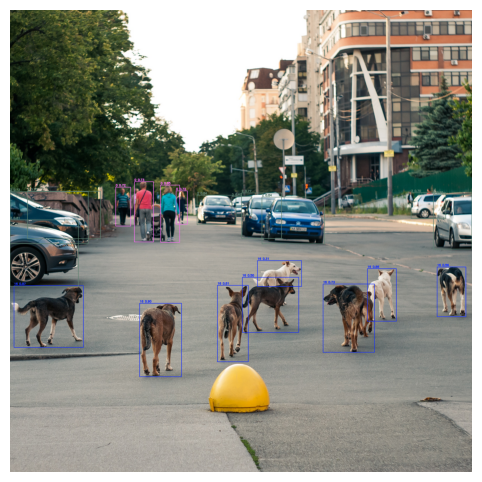

In [10]:
model= YOLO("yolov8n.pt")

image= Image.open('input/dogs_n_cars.jpg')
image= np.asarray(image)

results= model.predict(image)

boxes= results[0].boxes.xyxy
confs= results[0].boxes.conf
classes= results[0].boxes.cls

plot_bboxes(image, boxes, confs, classes, score= True)

------------

-------------

# Segmenttion

## command

### picture

In [11]:
!yolo task=segment mode=predict model='yolov8n-seg.pt' conf=0.5 source="input/dogs_n_cars.jpg" save=True

100% 6.74M/6.74M [00:00<00:00, 146MB/s]
Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-seg summary (fused): 195 layers, 3,404,320 parameters, 0 gradients, 12.6 GFLOPs

image 1/1 /content/gdrive/MyDrive/MacBook/Yolov8/input/dogs_n_cars.jpg: 640x640 4 persons, 8 cars, 6 dogs, 1 cow, 407.6ms
Speed: 8.6ms preprocess, 407.6ms inference, 93.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


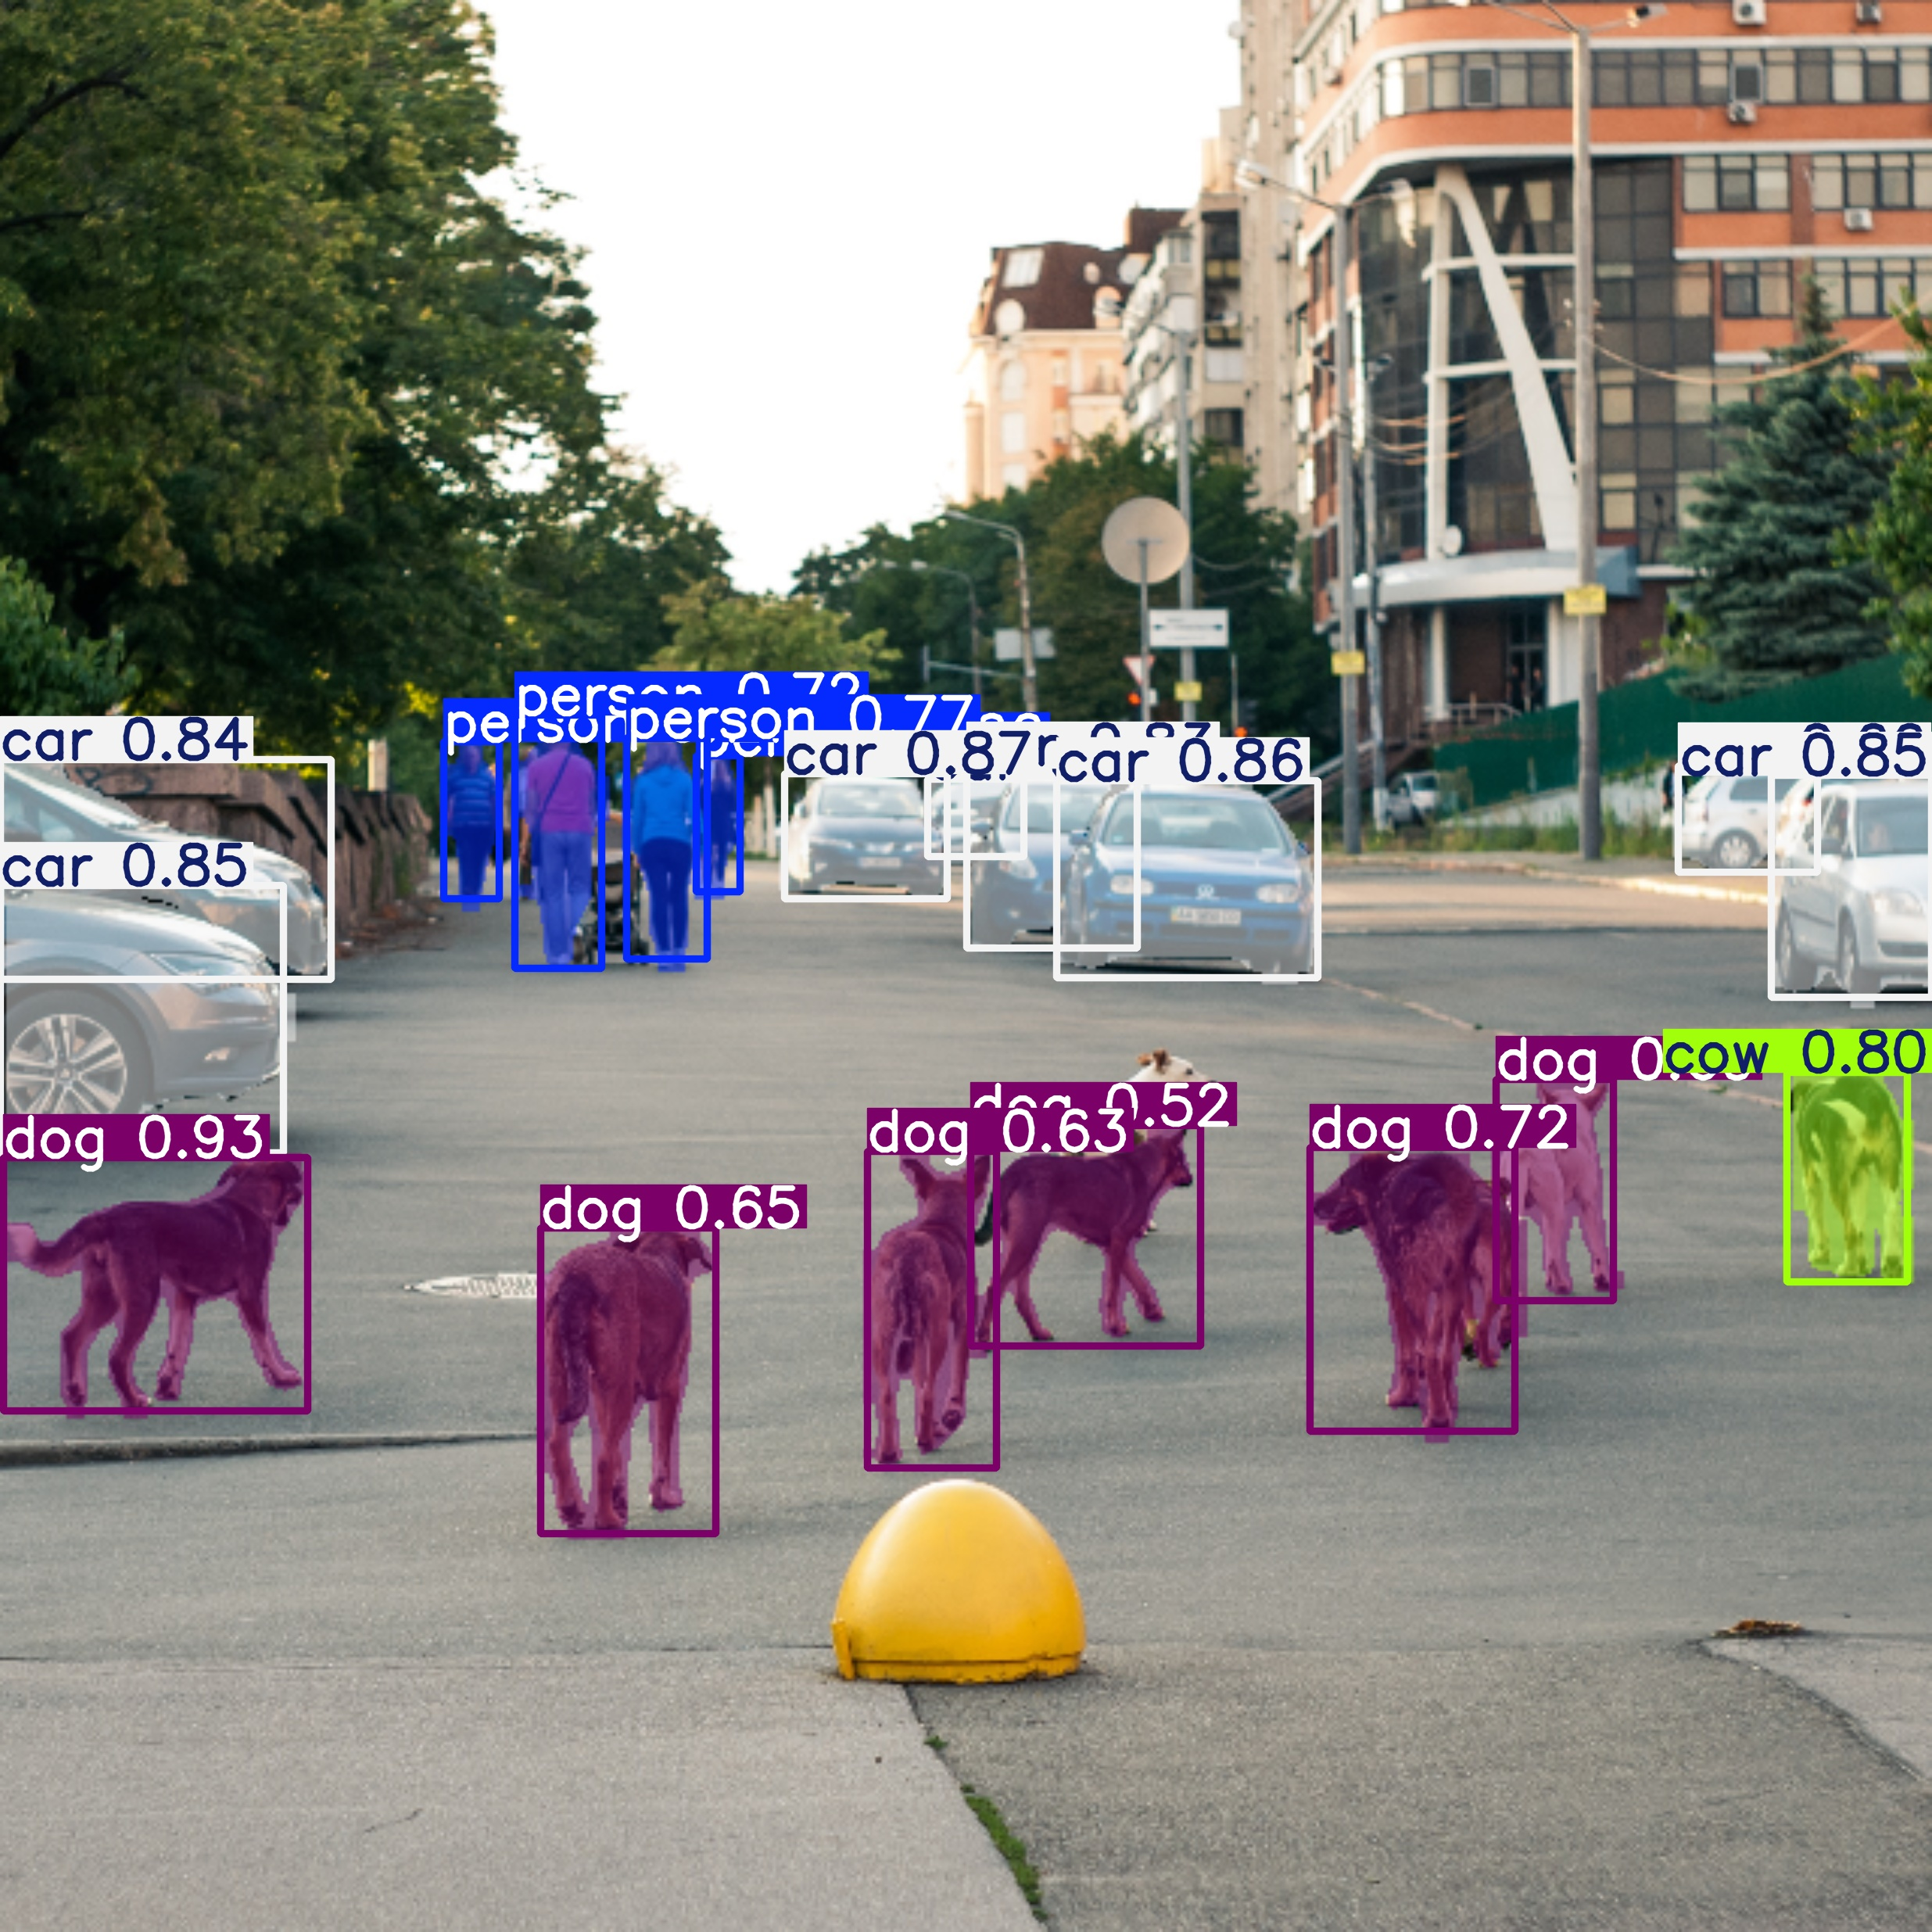

In [15]:
segment_path= '/content/gdrive/MyDrive/MacBook//Yolov8/runs/segment/predict/dogs_n_cars.jpg'
imgshow(segment_path, width = 600)

### video

In [13]:
!yolo task=segment mode=predict conf=0.5 source="input/test_vid.mp4" save=True

100% 5.90M/5.90M [00:00<00:00, 152MB/s]
Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11n-seg summary (fused): 265 layers, 2,868,664 parameters, 0 gradients, 10.4 GFLOPs

video 1/1 (frame 1/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 225.4ms
video 1/1 (frame 2/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 185.7ms
video 1/1 (frame 3/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 283.3ms
video 1/1 (frame 4/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 279.3ms
video 1/1 (frame 5/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 317.5ms
video 1/1 (frame 6/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 269.8ms
video 1/1 (frame 7/272) /content/gdrive/MyDrive/MacBook/Yolov8/input/test_vid.mp4: 384x640 7 persons, 286.2ms
video 1/1 (frame 8/272

---------------

## code


0: 640x640 4 persons, 11 cars, 6 dogs, 1 cow, 348.7ms
Speed: 10.2ms preprocess, 348.7ms inference, 98.2ms postprocess per image at shape (1, 3, 640, 640)


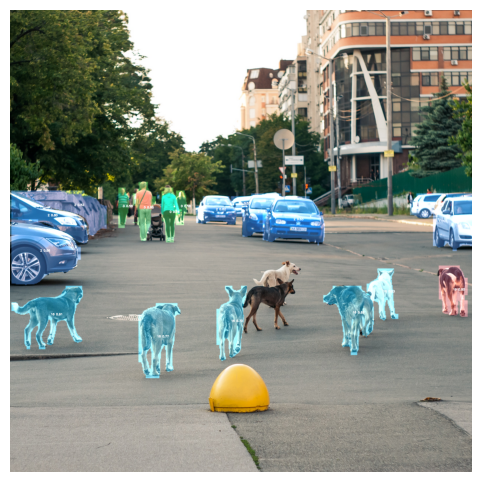

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from ultralytics import YOLO
from PIL import Image

def get_colors(classes):
    return {cls: (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)) for cls in classes}

def plot_masks(image, masks, classes, confs):
    img = image.copy()
    unique_classes = set(int(cls) for cls in classes.tolist())
    colors = get_colors(unique_classes)

    h, w, _ = img.shape

    for i, mask in enumerate(masks):
        if confs[i] < 0.5:
            continue

        mask = mask.cpu().numpy().astype(np.uint8) * 255
        mask = cv2.resize(mask, (w, h))
        color = colors[int(classes[i])]

        mask_colored = np.zeros_like(img)
        for c in range(3):
            mask_colored[:, :, c] = mask * (color[c] / 255.0)

        img = cv2.addWeighted(img, 1, mask_colored, 0.5, 0)

        x, y = np.where(mask > 0)
        if len(x) > 0 and len(y) > 0:
            x_center, y_center = int(np.mean(y)), int(np.mean(x))
            label = f"{int(classes[i])} {confs[i]:.2f}"
            cv2.putText(img, label, (x_center, y_center), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

model = YOLO("yolov8n-seg.pt")

image = Image.open('input/dogs_n_cars.jpg')
image = np.asarray(image)

results = model.predict(image)

masks = results[0].masks.data
classes = results[0].boxes.cls
confs = results[0].boxes.conf

plot_masks(image, masks, classes, confs)